# Library 로드 와 파일 불어오기

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks # 피크 검출 함수
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import os

#데이터 결로 확인
data_path = os.path.join(os.getcwd(), 'data','A_DeviceMotion_data')
if os.path.exists(data_path):
    print(f"데이터 경로 확인: {data_path}")
else:
    print("경로를 찾을 수 없습니다.")

데이터 경로 확인: /Users/linerenza/Desktop/비정형데이터분석/data/A_DeviceMotion_data


# 예제용 신호 생성

In [2]:
x = np.linspace(0,1,1024) #0~1 구간으로 샘플로 분할
#각 피크의 위치, 높이, 폭 설정
pos = np.array([0.10,0.13,0.15,0.23,0.25,0.40,0.44,0.65,0.76,0.78,0.81])
hgt = np.array([4.0,5.0,3.0,4.0,5.0,4.2,2.1,4.3,3.1,5.1,4.2])
wdt = np.array([0.005,0.005,0.006,0.01,0.01,0.03,0.01,0.01,0.005,0.008,0.005])

#빈 신호를 만든 뒤 여러 피크를 합쳐 예제 산호 생성
p_signal = np.zeros_like(x)
for p,h,w in zip(pos, hgt, wdt):
    p_signal += h/ (1 + np.abs((x-p)/w)) ** 4

In [3]:
# 피크 찾기
def peak_table(signal, threshold = 4.0, top_n = None):
    #입력 신호를 numpy 배열로 변환
    values = np.asarray(signal , dtype = float)
    #threshold 이상인 피크의 위치 와 높이 추출
    peak_idx, props = find_peaks(values, height = threshold)
    peaks = pd.DataFrame({
        "peak_height" : props['peak_heights'],
        "peak_index" : peak_idx
    }).sort_values("peak_height", ascending = False)

    return peaks.head(top_n) if top_n else peaks

#예제용 신호에서 확인
synthetic_peaks = peak_table(p_signal, threshold= 4.0, top_n = 3)
print(synthetic_peaks)

   peak_height  peak_index
0     4.972146         133
4     4.960051         798
1     4.590829         256


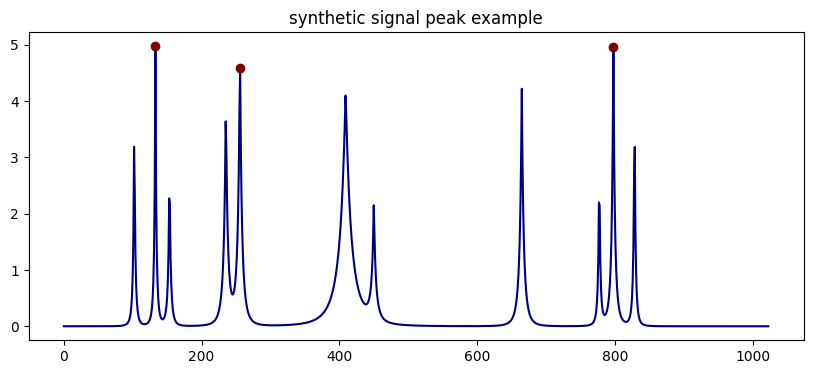

In [4]:
#시각화
plt.figure(figsize = (10,4))
plt.plot (p_signal, color = 'navy')
#결측된 피크만 점으로 다시 표시
plt.scatter(
    synthetic_peaks['peak_index'],
    synthetic_peaks['peak_height'],
    color = 'maroon',
    zorder = 3
)
plt.title ("synthetic signal peak example")
plt.show()

In [5]:
#피크에 대한 통계량 추출
#피크 위치를 오름차순으로 정렬
peak_positions = np.sort(synthetic_peaks['peak_index'].to_numpy())

# HAR_total data 준비

In [6]:
#har_total.pkl을 하나의 Dataframe으로 로드
har_total_path = os.path.join(data_path, 'HAR_total.pkl')
if os.path.exists(har_total_path):
    with open(har_total_path, 'rb') as f:
        har_total = pickle.load(f)
    print("HAR_total.pkl 파일이 성공적으로 로드되었습니다.")
else:
    print("HAR_total.pkl 파일을 찾을 수 없습니다.") 
display(har_total.head())

HAR_total.pkl 파일이 성공적으로 로드되었습니다.


,Unnamed: 0,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z,exp_no,id,activity,maguserAcceleration,magrotationRate
0,0,-2.116381,-1.077507,-2.261502,-0.404768,0.880780,0.245713,-1.264215,-1.027909,-0.947909,0.282683,-0.254346,-0.407670,11,12,dws,0.557491,1.885038
1,1,-2.148154,-1.049759,-2.284278,-0.417081,0.867303,0.271686,-1.162024,-0.269118,-0.848823,0.256712,0.079154,-0.560291,11,12,dws,0.621363,1.463976
2,2,-2.153824,-1.026749,-2.297008,-0.432082,0.855621,0.284961,-0.665042,0.520170,-0.726722,0.253600,0.346680,-0.463275,11,12,dws,0.631762,1.113994
3,3,-2.142509,-1.012749,-2.290595,-0.445311,0.848291,0.286507,-0.079809,0.055322,-0.604534,0.411818,0.459372,-0.510293,11,12,dws,0.800635,0.612284
4,4,-2.130486,-1.007262,-2.274149,-0.452661,0.845372,0.283600,0.456097,-0.186877,-0.441315,0.311594,0.477305,-0.925049,11,12,dws,1.086566,0.661594


In [7]:
print(har_total.shape)

(1412865, 18)


# 피크 관련 통계량
각 시퀀스를 하나의 실험 단위로 보고 특징을 계산

In [8]:
#시퀸스별 특징을 저장할 리스트
feature_rows = []
for (exp_no, sid, activity), group in har_total.groupby(["exp_no", "id","activity"], sort = True):
    #한 시퀀스의 rotation magnitude만 추출
    signal = group["magrotationRate"].to_numpy(dtype = float)

    peaks = peak_table(signal, threshold = 4.0)

    #peak 위치 / 높이/ 간격 계산
    peak_positions = np.sort(peaks["peak_index"].to_numpy()) if len(peaks) else np.array([])
    peak_values = peaks["peak_height"].to_numpy(dtype = float) if len(peaks) else np.array([])
    intervals = np.diff(peak_positions) if len(peaks) >= 2 else np.array([])


# peak 개수 / 간격 특징
피크 개수 와 간격은 dict로 저장

In [9]:
row = {
    "f_n" : int(len(peaks)), #전제 피크 개수
    "p_interval" : float(intervals.mean()) if len (intervals) else 0.0, # 간격 평균
    "p_interval_std": float(intervals.std(ddof = 1)) if len(intervals) >= 2 else 0.0, #간격 표준편차
}
display(row)

{'f_n': 748,
 'p_interval': 5.139223560910308,
 'p_interval_std': 3.2396506178223508}

In [10]:
row.update({
    # 피크 높이의 평균값
    "p_mean": float(peak_values.mean()) if len(peak_values) else 0.0,

    # 가장 큰 피크 높이
    "p_max": float(peak_values.max()) if len(peak_values) else 0.0,

    # 가장 작은 피크 높이
    "p_min": float(peak_values.min()) if len(peak_values) else 0.0,

    # 피크 높이의 표준편차
    "p_std": float(peak_values.std(ddof=1)) if len(peak_values) >= 2 else 0.0,
})
display(row)

{'f_n': 748,
 'p_interval': 5.139223560910308,
 'p_interval_std': 3.2396506178223508,
 'p_mean': 6.6732261583701336,
 'p_max': 14.417551302350688,
 'p_min': 4.002344726251975,
 'p_std': 1.708047761678218}

In [11]:
#exp_no and id datatype object이다

example = har_total.query(
    "exp_no == '1' and id == '1' and activity == 'dws'"
).copy()
display(example)

,Unnamed: 0,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z,exp_no,id,activity,maguserAcceleration,magrotationRate
904668,0,1.528132,-0.733896,0.696372,0.741895,0.669768,-0.031672,0.316738,0.778180,1.082764,0.294894,-0.184493,0.377542,1,1,dws,0.513360,1.370498
904669,1,1.527992,-0.716987,0.677762,0.753099,0.657116,-0.032255,0.842032,0.424446,0.643574,0.219405,0.035846,0.114866,1,1,dws,0.250235,1.141648
904670,2,1.527765,-0.706999,0.670951,0.759611,0.649555,-0.032707,-0.138143,-0.040741,0.343563,0.010714,0.134701,-0.167808,1,1,dws,0.215450,0.372530
904671,3,1.516768,-0.704678,0.675735,0.760709,0.647788,-0.041140,-0.025005,-1.048717,0.035860,-0.008389,0.136788,0.094958,1,1,dws,0.166728,1.049628
904672,4,1.493941,-0.703918,0.672994,0.760062,0.647210,-0.058530,0.114253,-0.912890,0.047341,0.199441,0.353996,-0.044299,1,1,dws,0.408720,0.921229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
906414,1746,1.797120,-0.562324,2.445889,0.824443,0.533154,0.189844,-0.123211,0.909536,-0.379757,-0.268367,0.006733,-0.064874,1,1,dws,0.276179,0.993304
906415,1747,1.814297,-0.569719,2.449655,0.817212,0.539396,0.203020,-0.057641,0.723118,-0.437812,-0.102444,-0.060666,-0.229738,1,1,dws,0.258756,0.847291
906416,1748,1.830821,-0.578367,2.447967,0.809207,0.546658,0.215288,0.343238,0.997236,-0.338155,-0.085590,-0.030209,-0.087740,1,1,dws,0.126240,1.107538
906417,1749,1.849557,-0.586962,2.439458,0.800485,0.553834,0.229110,0.470144,1.227937,-0.332223,-0.048105,0.029555,0.060441,1,1,dws,0.082709,1.356185


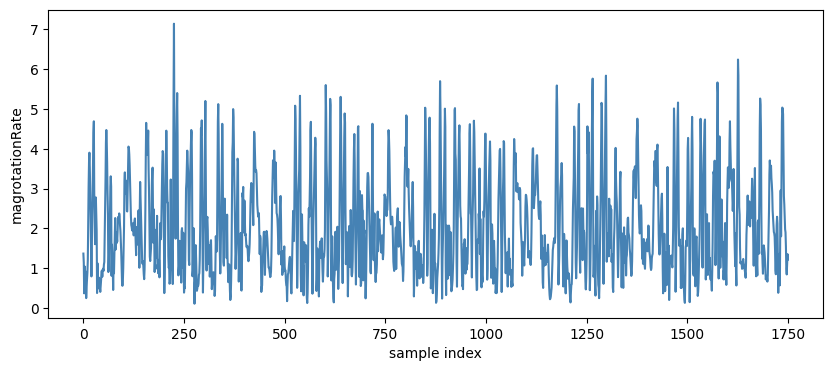

In [12]:
#시각화
#예제 시퀀스의 rotation magnitude를 선 그래프로 표시
plt.figure(figsize = (10,4))
plt.plot(example['magrotationRate'].to_numpy(),
         color = 'steelblue')
plt.xlabel("sample index")
plt.ylabel("magrotationRate")
plt.show()

In [13]:
#예제 시퀀스에서 5.0 이상인 강한 피크만 추출
example_peaks = peak_table(
    example['magrotationRate'],
    threshold = 5.0
)
display(example_peaks)

,peak_height,peak_index
0,7.138682,225
21,6.239476,1626
17,5.835136,1298
15,5.761030,1265
10,5.696929,886
20,5.664433,1575
6,5.599312,602
13,5.588782,1176
1,5.398592,233
5,5.330121,538


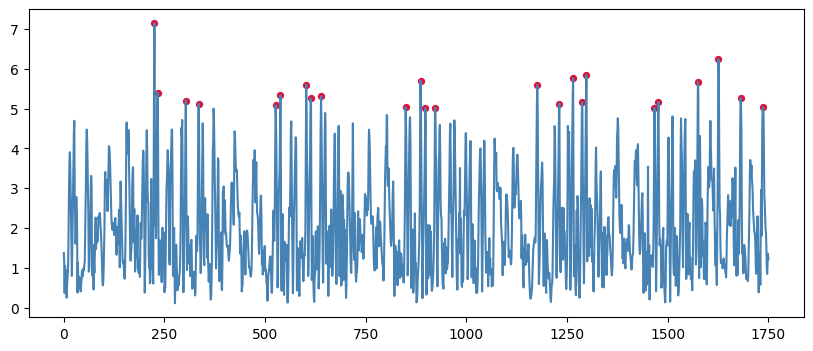

In [14]:
#원래 시계열 위에 피크 위치를 빨간 점으로 겹처 그림
plt.figure(figsize = (10,4))
plt.plot(example['magrotationRate'].to_numpy(), color = 'steelblue')
plt.scatter(example_peaks['peak_index'],
            example_peaks['peak_height'],
            color = 'crimson', s= 18)
plt.show()

## 파고율 구하기

In [15]:
def crest_factor(x):
    """신호에서 “얼마나 큰 피크(튀는 값)가 있는지”를 보는 지표"""
    # RMS (root mean square) 계산
    values = np.asarray(x, dtype=float)
    rms = np.sqrt(np.mean(values ** 2))

    # RMS가 0이면 0, 아니면 최대 절댓값 / RMS 반환
    if rms == 0:
        return 0.0
    return float(np.max(np.abs(values)) / rms)


# rotation / acceleration 각각의 crest factor 계산
cfr = crest_factor(example["magrotationRate"])
cfa = crest_factor(example["maguserAcceleration"])

## 파고율 계산 반복

In [16]:
feature_rows = []
for (exp_no, sid, activity), group in har_total.groupby(["exp_no", "id", "activity"], sort=True):
    # rotation magnitude 추출
    signal = group["magrotationRate"].to_numpy(dtype=float)

    # peak table 생성
    peaks = peak_table(signal, threshold=4.0)

    # peak 위치 / 높이 / 간격
    peak_positions = np.sort(peaks["peak_index"].to_numpy()) if len(peaks) else np.array([])
    peak_values = peaks["peak_height"].to_numpy(dtype=float) if len(peaks) else np.array([])
    intervals = np.diff(peak_positions) if len(peaks) >= 2 else np.array([])

    # 기본 특징
    row = {
        "f_n": int(len(peaks)),
        "p_interval": float(intervals.mean()) if len(intervals) else 0.0,
        "p_interval_std": float(intervals.std(ddof=1)) if len(intervals) >= 2 else 0.0,
        "p_mean": float(peak_values.mean()) if len(peak_values) else 0.0,
        "p_max": float(peak_values.max()) if len(peak_values) else 0.0,
        "p_min": float(peak_values.min()) if len(peak_values) else 0.0,
        "p_std": float(peak_values.std(ddof=1)) if len(peak_values) >= 2 else 0.0,
    }

    # acceleration magnitude 추출
    accel = group["maguserAcceleration"].to_numpy(dtype=float)

    # crest factor 추가
    row.update({
        "cfr": crest_factor(signal),
        "cfa": crest_factor(accel),
    })

    # 한 시퀀스당 한 행 저장
    feature_rows.append({
        "sequence_key": f"exp_{exp_no}_id_{sid}_{activity}",
        "exp_no": exp_no,
        "id": sid,
        "activity": activity,
        **row
    })

In [17]:
#리스트에 쌓아둔 특징을 dataframe으로 변환
peak_final = pd.DataFrame(feature_rows)
#컬럼 순서 정리
peak_final = peak_final[[
    "sequence_key","exp_no","id","activity",
    "f_n","p_interval","p_interval_std","p_mean","p_max",
    "p_min","p_std","cfr","cfa"
]]
display(peak_final)

,sequence_key,exp_no,id,activity,f_n,p_interval,p_interval_std,p_mean,p_max,p_min,p_std,cfr,cfa
0,exp_1_id_1_dws,1,1,dws,67,25.909091,18.497174,4.821695,7.138682,4.013819,0.571169,2.992226,3.456021
1,exp_1_id_10_dws,1,10,dws,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.549224,3.510066
2,exp_1_id_11_dws,1,11,dws,16,128.866667,157.651907,4.151319,4.465340,4.000085,0.147131,2.201655,4.153525
3,exp_1_id_12_dws,1,12,dws,90,16.865169,18.395399,5.146957,9.340254,4.006383,1.263152,3.289149,5.318040
4,exp_1_id_13_dws,1,13,dws,46,34.777778,33.163431,4.464274,5.246849,4.025133,0.328732,2.238085,3.934568
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,exp_9_id_5_jog,9,5,jog,239,14.840336,6.217551,5.076605,7.039267,4.016397,0.443038,2.304248,3.116643
356,exp_9_id_6_jog,9,6,jog,590,7.178268,5.779432,5.948539,17.601996,4.002710,1.658114,4.732604,4.789707
357,exp_9_id_7_jog,9,7,jog,343,13.190058,9.114882,4.981133,6.970203,4.000603,0.693778,2.398520,3.987310
358,exp_9_id_8_jog,9,8,jog,19,218.277778,266.954899,4.191888,4.640206,4.021614,0.175551,2.318616,3.830996


## activity 구분

In [18]:
# activity 분류에 사용할 입력 특징 목록
feature_cols = [
    "f_n", "p_interval", "p_interval_std",
    "p_mean", "p_max", "p_min", "p_std",
    "cfr", "cfa",
]

# 결측치는 0으로 채워 학습용 행렬 생성
X = peak_final[feature_cols].fillna(0.0)

# 예측 대상은 activity 라벨
y = peak_final["activity"]

# 랜덤포레스트 분류기 생성
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

## 10fold 평가

In [19]:
# 클래스 비율을 유지하는 10-fold 교차검증 설정
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# 각 fold의 accuracy 계산
accuracy = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("mean accuracy:", accuracy.mean())
print("std:", accuracy.std(ddof=1))
print(f"Number of sequences: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

mean accuracy: 0.663888888888889
std: 0.08730258938017162
Number of sequences: 360
Number of features: 9


# (연습문제) 통계 특징과 피크 특징을 함꼐 사용해 10-fold 수행

In [20]:
#har_total
display(har_total.head())
print(har_total.shape)

,Unnamed: 0,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z,exp_no,id,activity,maguserAcceleration,magrotationRate
0,0,-2.116381,-1.077507,-2.261502,-0.404768,0.880780,0.245713,-1.264215,-1.027909,-0.947909,0.282683,-0.254346,-0.407670,11,12,dws,0.557491,1.885038
1,1,-2.148154,-1.049759,-2.284278,-0.417081,0.867303,0.271686,-1.162024,-0.269118,-0.848823,0.256712,0.079154,-0.560291,11,12,dws,0.621363,1.463976
2,2,-2.153824,-1.026749,-2.297008,-0.432082,0.855621,0.284961,-0.665042,0.520170,-0.726722,0.253600,0.346680,-0.463275,11,12,dws,0.631762,1.113994
3,3,-2.142509,-1.012749,-2.290595,-0.445311,0.848291,0.286507,-0.079809,0.055322,-0.604534,0.411818,0.459372,-0.510293,11,12,dws,0.800635,0.612284
4,4,-2.130486,-1.007262,-2.274149,-0.452661,0.845372,0.283600,0.456097,-0.186877,-0.441315,0.311594,0.477305,-0.925049,11,12,dws,1.086566,0.661594


(1412865, 18)


In [21]:
#peak_final
display(peak_final.head())
print(peak_final.shape)

,sequence_key,exp_no,id,activity,f_n,p_interval,p_interval_std,p_mean,p_max,p_min,p_std,cfr,cfa
0,exp_1_id_1_dws,1,1,dws,67,25.909091,18.497174,4.821695,7.138682,4.013819,0.571169,2.992226,3.456021
1,exp_1_id_10_dws,1,10,dws,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.549224,3.510066
2,exp_1_id_11_dws,1,11,dws,16,128.866667,157.651907,4.151319,4.465340,4.000085,0.147131,2.201655,4.153525
3,exp_1_id_12_dws,1,12,dws,90,16.865169,18.395399,5.146957,9.340254,4.006383,1.263152,3.289149,5.318040
4,exp_1_id_13_dws,1,13,dws,46,34.777778,33.163431,4.464274,5.246849,4.025133,0.328732,2.238085,3.934568


(360, 13)


In [28]:
#결과 저장
csv_path = f"{data_path}/HAR_Peak_Analysis.csv"
pkl_path = f"{data_path}/HAR_Peak_Analysis.pkl"

peak_final.to_csv(csv_path, index=False)
peak_final.to_pickle(pkl_path)

print("저장 완료")

저장 완료


In [22]:
from scipy.stats import skew, iqr, kurtosis

#통계 특징
def rms(x):
    return np.sqrt(np.mean(np.square(x)))

def rss(x):
    return np.sqrt(np.sum(np.square(x)))

# 그룹별 다양한 통계량 한 번에 추출
har_summary_extend = (
    har_total
    .groupby(['id', 'exp_no', 'activity'])
    .agg(
        magAcc_mean=('maguserAcceleration', 'mean'),
        magAcc_sd=('maguserAcceleration', 'std'),
        magAcc_skew=('maguserAcceleration', lambda x: skew(x, bias=False)),
        magAcc_rms=('maguserAcceleration', rms),
        magAcc_rss=('maguserAcceleration', rss),
        magAcc_iqr=('maguserAcceleration', lambda x: iqr(x, rng=(25, 75))),
        magAcc_kurt=('maguserAcceleration', lambda x: kurtosis(x, fisher=False, bias = False)),

        magRot_mean=('magrotationRate', 'mean'),
        magRot_sd=('magrotationRate', 'std'),
        magRot_skew=('magrotationRate', lambda x: skew(x, bias=False)),
        magRot_rms=('magrotationRate', rms),
        magRot_rss=('magrotationRate', rss),
        magRot_iqr=('magrotationRate', lambda x: iqr(x, rng=(25, 75))),
        magRot_kurt=('magrotationRate', lambda x: kurtosis(x, fisher=False, bias = False))
    )
    .reset_index()
)

In [23]:
#add sequence keys to har_summary_extend
har_summary_extend["sequence_key"] = (
    "exp_" + har_summary_extend["exp_no"].astype(str) +
    "_id_" + har_summary_extend["id"].astype(str) +
    "_" + har_summary_extend["activity"]
)
har_summary_extend = har_summary_extend[
    ["sequence_key", "exp_no", "id", "activity"] +
    [col for col in har_summary_extend.columns if col not in ["sequence_key", "exp_no", "id", "activity"]]
]
display(har_summary_extend.head())

,sequence_key,exp_no,id,activity,magAcc_mean,magAcc_sd,magAcc_skew,magAcc_rms,magAcc_rss,magAcc_iqr,magAcc_kurt,magRot_mean,magRot_sd,magRot_skew,magRot_rms,magRot_rss,magRot_iqr,magRot_kurt
0,exp_1_id_1_dws,1,1,dws,0.501065,0.262767,1.140624,0.565750,23.673799,0.336092,5.204329,2.050740,1.219460,0.803248,2.385742,99.831278,1.705448,3.011956
1,exp_11_id_1_dws,11,1,dws,0.508985,0.279252,1.499335,0.580483,17.375745,0.331943,7.360827,2.079373,1.218075,0.726392,2.409531,72.125131,1.719327,2.915536
2,exp_12_id_1_ups,12,1,ups,0.480549,0.265723,1.511764,0.549062,17.926694,0.343959,8.182422,2.474843,1.302956,0.800285,2.796596,91.307900,1.838639,3.350890
3,exp_13_id_1_sit,13,1,sit,0.017672,0.015293,5.197941,0.023370,2.370859,0.010806,54.387429,0.044123,0.066350,4.943210,0.079679,8.083395,0.036880,38.845216
4,exp_14_id_1_std,14,1,std,0.025681,0.017401,1.863807,0.031019,1.567308,0.018296,7.560645,0.078551,0.075889,2.236386,0.109211,5.518133,0.085203,10.373218


## Statistical Feature 분석 + peak 특징 분석결과 합치고 예측

In [24]:
#두 테이블 합치기 (통계 특징 + peak 특징)

final_df = pd.merge(
    har_summary_extend,
    peak_final,
    on=["sequence_key", "exp_no", "id", "activity"],
    how="inner"
)
print(final_df.shape)
display(final_df.head())

(360, 27)


,sequence_key,exp_no,id,activity,magAcc_mean,magAcc_sd,magAcc_skew,magAcc_rms,magAcc_rss,magAcc_iqr,...,magRot_kurt,f_n,p_interval,p_interval_std,p_mean,p_max,p_min,p_std,cfr,cfa
0,exp_1_id_1_dws,1,1,dws,0.501065,0.262767,1.140624,0.565750,23.673799,0.336092,...,3.011956,67,25.909091,18.497174,4.821695,7.138682,4.013819,0.571169,2.992226,3.456021
1,exp_11_id_1_dws,11,1,dws,0.508985,0.279252,1.499335,0.580483,17.375745,0.331943,...,2.915536,38,23.513514,19.184226,4.653541,6.627259,4.004458,0.636398,2.750435,3.882361
2,exp_12_id_1_ups,12,1,ups,0.480549,0.265723,1.511764,0.549062,17.926694,0.343959,...,3.350890,50,20.795918,16.332457,5.185460,7.239072,4.041368,0.833111,2.588530,3.941039
3,exp_13_id_1_sit,13,1,sit,0.017672,0.015293,5.197941,0.023370,2.370859,0.010806,...,38.845216,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.627549,12.206843
4,exp_14_id_1_std,14,1,std,0.025681,0.017401,1.863807,0.031019,1.567308,0.018296,...,10.373218,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.925252,4.717860


In [25]:
# activity 분류에 사용할 입력 특징 목록
feature_cols_summary = [
    col for col in har_summary_extend.columns
    if col not in ["sequence_key", "exp_no", "id", "activity"]
]
feature_cols_peak = [
    col for col in peak_final.columns
    if col not in ["sequence_key", "exp_no", "id", "activity"]
]
feature_cols = feature_cols_summary + feature_cols_peak

# 결측치는 0으로 채워 학습용 행렬 생성
X = final_df[feature_cols].fillna(0.0)

# 예측 대상은 activity 라벨
y = final_df["activity"]

# 랜덤포레스트 분류기 생성
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

In [26]:
#10fold 평가
# 클래스 비율을 유지하는 10-fold 교차검증 설정
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# 각 fold의 accuracy 계산
accuracy = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("mean accuracy:", accuracy.mean())
print("std:", accuracy.std(ddof=1))
print(f"Number of sequences: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

mean accuracy: 0.8777777777777779
std: 0.049344120720274894
Number of sequences: 360
Number of features: 23
